예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:
# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)
# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 케라스 API로 다시 쓰는 6-3절

> **추가 학습 자료** — 본문 6-3절 「순서를 기준으로 판단하는 모델 만들기」
> 선수 지식: 6-1절(순환 신경망의 구조), 6-2절(`nn.RNN`), 6-3절(띄어쓰기 모델, LSTM)
> 앞선 글: [케라스 API로 다시 쓰는 합성곱 신경망](../keras-api-1/) — 백엔드 설정과 `fit()`의 기본

앞선 글에서 5-3절의 합성곱 신경망을 케라스로 옮겼다. 그때는 두 구현의 파라미터 수가
532,970개로 **정확히 일치**했다. 같은 모델을 다른 표기법으로 적은 것이 맞다는 증거였다.

이 노트북에서는 6-3절의 띄어쓰기 모델을 케라스로 옮긴다. 그런데 이번에는 파라미터 수가
**일치하지 않는다.** 구현을 잘못해서가 아니다. 두 프레임워크가 순환 신경망의 수식을
서로 다르게 구현하기 때문이다. 이 노트북의 절반은 그 차이가 어디에서 오는지 밝히는 데 쓴다.

다루는 내용
- 1절 데이터 준비 — 본문 [코드 6-11]~[코드 6-13]을 **그대로** 사용
- 2절 `nn.RNN`을 `layers.SimpleRNN`으로 — `return_sequences`와 계층 쌓기
- 3절 파라미터 수가 왜 다른가 — 편향 벡터가 하나냐 둘이냐
- 4절 학습 — 기울기 클리핑을 옵티마이저 인자로
- 5절 예측 — 슬라이딩 윈도우를 한 번에
- 6절 LSTM으로 교체 — 본문 [코드 6-17]과 대칭

## 0. 백엔드 지정

[앞선 글](../keras-api-1/)에서 설명한 것과 같다. `keras`를 임포트하기 **전에**
환경 변수로 백엔드를 정한다. 다만 이 노트북의 입력은 이미지가 아니라 순차 데이터이므로
`set_image_data_format()`은 필요 없다. 순차 데이터의 형태 `(B, S, input_size)`는
두 프레임워크가 같은 순서를 쓰기 때문이다.

In [2]:
import os
# 반드시 keras를 임포트하기 전에 지정해야 함
os.environ['KERAS_BACKEND'] = 'torch'

import keras
import torch

print(f'케라스 버전: {keras.__version__}')
print(f'백엔드: {keras.backend.backend()}')

SEED = 42
keras.utils.set_random_seed(SEED)       # random, numpy, torch 시드를 한 번에 고정

케라스 버전: 3.15.1
백엔드: torch


## 1. 데이터 준비 — 본문 [코드 6-11]~[코드 6-13]을 그대로

이 절의 코드는 본문과 **한 글자도 다르지 않다.** 순차 데이터를 만들고, 어휘 사전을 만들고,
`Dataset`과 `DataLoader`로 미니배치를 구성하는 일은 모두 파이토치가 그대로 맡는다.
케라스가 가져가는 것은 모델을 정의하고 학습시키는 부분뿐이다.

In [3]:
# 본문 [코드 6-11] - 원본 문자열에서 입력과 정답 문자열 만들기
import re

# 입력 문자열(input_text)에 대응하는 정답 문자열을 만드는 함수
def making_spacing_example(input_text):
    # 문자열 앞뒤의 공백 문자를 제거하고 대문자를 소문자로 변환
    input_text = input_text.strip().lower()
    # 공백 문자를 모두 제거한 입력 순차 데이터
    input_sequence = ''.join(char for char in input_text if not char.isspace())
    # 공백 위치를 1, 나머지를 0으로 표기한 뒤, 문자열 끝에도 1을 하나 붙임
    space_location = ''.join(
        '1' if char.isspace() else '0' for char in input_text
    ) + '1'
    # 연속된 공백(01, 011, ...)을 하나의 공백(1)으로 정규화
    target_sequence = re.sub('01+', '1', space_location)
    return input_sequence, target_sequence


original_text = 'I love you.'
test_in, test_tar = making_spacing_example(original_text)
print(f'원본 문장: {original_text}')
print(f'입력: {test_in} (길이 {len(test_in)})')
print(f'정답: {test_tar} (길이 {len(test_tar)})')

원본 문장: I love you.
입력: iloveyou. (길이 9)
정답: 100010001 (길이 9)


In [4]:
# 본문 [코드 6-12] - 띄어쓰기 데이터셋 클래스
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


class SpacingDataset(Dataset):
    def __init__(self, input_sequence, target_sequence, vocab, window_size):
        self.vocab = vocab
        self.window_size = window_size
        self.target_sequence = target_sequence
        self.sequence_idx = torch.tensor(
            [vocab[token] for token in input_sequence]
        )

    def __len__(self):
        return len(self.sequence_idx) - self.window_size + 1

    def __getitem__(self, idx):
        subsequence = self.sequence_idx[idx: idx + self.window_size]
        # 입력: 윈도우 내 문자들의 원-핫 텐서(실수형 텐서)
        x = F.one_hot(subsequence, num_classes=len(self.vocab)).float()
        # 정답: 윈도우 마지막 글자 뒤의 띄어쓰기 여부(0 또는 1, long형 텐서)
        target = self.target_sequence[idx + self.window_size - 1]
        y = torch.tensor(int(target), dtype=torch.long)
        return x, y

In [5]:
# 본문 [코드 6-13] - 띄어쓰기 모델의 학습 데이터 준비
from pathlib import Path

text_path = Path('../../data/wonderful_wizard_of_oz.txt')
text = text_path.read_text(encoding='utf-8-sig')

# 소설 <오즈의 마법사> 텍스트(text)로 어휘 사전 생성
input_sequence, target_sequence = making_spacing_example(text)
vocab = {token: i for i, token in enumerate(sorted(set(input_sequence)))}
vocab_size = len(vocab)                 # 어휘 사전의 크기(input_size)

SEQUENCE_LENGTH = 25                    # 입력 샘플의 길이(S)
spacing_dataset = SpacingDataset(
    input_sequence, target_sequence, vocab, SEQUENCE_LENGTH,
)

BATCH_SIZE = 128                        # 배치 크기(B)
spacing_dataloader = DataLoader(
    spacing_dataset, batch_size=BATCH_SIZE, shuffle=True,
)

print(f'어휘 사전 크기: {vocab_size}')
print(f'데이터셋의 샘플 수: {len(spacing_dataset)}개')
print(f'미니배치의 개수: {len(spacing_dataloader)}개')

어휘 사전 크기: 61
데이터셋의 샘플 수: 182769개
미니배치의 개수: 1428개


## 2. `nn.RNN`을 `layers.SimpleRNN`으로

본문 [코드 6-14]의 `SpacingRNN`은 이렇게 생겼다.

```python
class SpacingRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):                   # (B, S, input_size)
        outputs, _ = self.rnn(x)            # -> (B, S, hidden_size)
        last_hidden = outputs[:, -1, :]     # -> (B, hidden_size)
        return self.fc(last_hidden)         # -> (B, output_size)
```

케라스로 옮기면 이렇게 된다.

```python
model = keras.Sequential([
    layers.Input(shape=(SEQUENCE_LENGTH, vocab_size)),
    layers.SimpleRNN(HIDDEN_SIZE, return_sequences=True),
    layers.SimpleRNN(HIDDEN_SIZE),
    layers.Dense(OUTPUT_SIZE),
])
```

네 줄짜리 생성자 인자와 네 줄짜리 `forward()`가 세 줄로 줄었다. 무엇이 어디로 갔는지 보자.

### `batch_first=True`가 사라진다

파이토치의 `nn.RNN`은 기본적으로 입력을 `(S, B, input_size)` 형태로 받는다.
시간 축이 먼저 오는 것이 순환 신경망의 계산 순서와 맞기 때문인데, 다른 계층과 형태가 달라
헷갈리기 쉬워 본문은 `batch_first=True`를 주어 `(B, S, input_size)`로 맞췄다.

케라스는 **언제나 배치가 먼저**다. 고를 것이 없으니 인자도 없다.

### `num_layers=2`가 사라지고 계층이 두 개가 된다

파이토치의 `nn.RNN`은 `num_layers` 인자 하나로 순환 계층을 수직으로 쌓는다.
계층 두 개가 `self.rnn` 하나 안에 들어 있는 셈이다.

케라스의 `SimpleRNN`은 **한 계층이 한 계층이다.** 두 개를 쌓으려면 두 번 적는다.
코드는 길어지지만, 계층마다 크기를 다르게 주거나 사이에 드롭아웃을 끼워 넣기가 쉽다.

### `outputs[:, -1, :]`가 `return_sequences`로 바뀐다

여기가 가장 중요하다. 파이토치의 `nn.RNN`은 **모든 시점의 출력을 돌려주고**, 필요한 것만
골라 쓰는 일은 사용자의 몫이다. 본문이 `outputs[:, -1, :]`로 마지막 시점만 잘라 낸 것이 그것이다.

케라스는 계층을 만들 때 `return_sequences`로 미리 정한다.

| | 출력 형태 | 쓰는 곳 |
|---|---|---|
| `return_sequences=True` | `(B, S, hidden_size)` | 뒤에 순환 계층을 더 쌓을 때 |
| `return_sequences=False` (기본값) | `(B, hidden_size)` | 마지막 시점만 필요할 때 |

두 계층을 쌓으므로 **첫 번째는 `True`**(다음 순환 계층이 모든 시점을 받아야 하니까),
**두 번째는 기본값 `False`**(본문의 `outputs[:, -1, :]`에 해당)가 된다.

`return_sequences=True`를 빠뜨리는 것이 케라스에서 순환 신경망을 쌓을 때 가장 흔한 실수다.
이때는 두 번째 계층이 시간 축이 없는 `(B, hidden_size)`를 받게 되어 형태 오류가 난다.
`from_logits`와 달리 조용히 넘어가지 않고 바로 오류를 내 주는 것이 그나마 다행이다.

In [6]:
from keras import layers

# 모델의 구조를 결정하는 하이퍼파라미터(본문 [코드 6-14]와 동일)
INPUT_SIZE = vocab_size                     # 순환 계층의 input_size
HIDDEN_SIZE = 256                           # 순환 계층의 hidden_size
NUM_LAYERS = 2                              # 순환 계층의 수직 배치 계수
OUTPUT_SIZE = 2                             # 띄어쓰거나 않거나의 두 개의 클래스


# 본문 SpacingRNN / SpacingLSTM 과 같은 구조의 모델을 만드는 함수
#   cell_layer: layers.SimpleRNN 또는 layers.LSTM
def build_spacing_model(cell_layer):
    model_layers = [layers.Input(shape=(SEQUENCE_LENGTH, INPUT_SIZE))]
    # 마지막 순환 계층을 제외한 나머지는 모든 시점의 출력을 다음 계층에 넘김
    for _ in range(NUM_LAYERS - 1):
        model_layers.append(cell_layer(HIDDEN_SIZE, return_sequences=True))
    # 마지막 순환 계층: 마지막 시점의 출력만 반환(본문의 outputs[:, -1, :] 에 해당)
    model_layers.append(cell_layer(HIDDEN_SIZE))
    # 완전 연결 계층(분류기)
    model_layers.append(layers.Dense(OUTPUT_SIZE))
    return keras.Sequential(model_layers)


model_rnn = build_spacing_model(layers.SimpleRNN)
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 25, 256)        │        81,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,250 (833.01 KB)

 Trainable params: 213,250 (833.01 KB)

 Non-trainable params: 0 (0.00 B)

## 3. 파라미터 수가 왜 다른가

본문의 `SpacingRNN`과 나란히 놓고 파라미터를 하나씩 대조해 보자.

In [7]:
# 본문 [코드 6-14]의 파이토치 모델
import torch.nn as nn


class SpacingRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):                   # 입력 데이터 x: (B, S, input_size)
        outputs, _ = self.rnn(x)            #             -> (B, S, hidden_size)
        last_hidden = outputs[:, -1, :]     #             -> (B, hidden_size)
        return self.fc(last_hidden)         #             -> (B, output_size)


torch_rnn = SpacingRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)

torch_total = common.count_params(torch_rnn)
keras_total = model_rnn.count_params()
print(f'파이토치 SpacingRNN : {torch_total:,}')
print(f'케라스   SimpleRNN  : {keras_total:,}')
print(f'차이                : {torch_total - keras_total:,}')

파이토치 SpacingRNN : 213,762
케라스   SimpleRNN  : 213,250
차이                : 512


In [8]:
# 파라미터를 하나씩 대조
import numpy as np

print('파이토치')
for name, param in torch_rnn.named_parameters():
    print(f'  {name:<20} {tuple(param.shape)!s:<14} {param.numel():>8,}')

print('\n케라스')
for weight in model_rnn.weights:
    # 경로가 길어 계층 이름과 파라미터 이름만 남김
    parts = weight.path.split('/')
    short_name = f'{parts[1]}/{parts[-1]}'
    print(f'  {short_name:<28} {tuple(weight.shape)!s:<14} '
          f'{int(np.prod(weight.shape)):>8,}')

파이토치
  rnn.weight_ih_l0     (256, 61)        15,616
  rnn.weight_hh_l0     (256, 256)       65,536
  rnn.bias_ih_l0       (256,)              256
  rnn.bias_hh_l0       (256,)              256
  rnn.weight_ih_l1     (256, 256)       65,536
  rnn.weight_hh_l1     (256, 256)       65,536
  rnn.bias_ih_l1       (256,)              256
  rnn.bias_hh_l1       (256,)              256
  fc.weight            (2, 256)            512
  fc.bias              (2,)                  2

케라스
  simple_rnn/kernel            (61, 256)        15,616
  simple_rnn/recurrent_kernel  (256, 256)       65,536
  simple_rnn/bias              (256,)              256
  simple_rnn_1/kernel          (256, 256)       65,536
  simple_rnn_1/recurrent_kernel (256, 256)       65,536
  simple_rnn_1/bias            (256,)              256
  dense/kernel                 (256, 2)            512
  dense/bias                   (2,)                  2


두 가지가 눈에 띈다.

### 가중치 행렬은 전치되어 있을 뿐 크기가 같다

파이토치의 `weight_ih_l0`은 `(256, 61)`이고, 케라스의 `kernel`은 `(61, 256)`이다.
행과 열이 뒤바뀌어 있지만 원소 수는 15,616개로 같다.

이것은 계산을 적는 방향의 차이다. 파이토치의 `nn.Linear`는 `y = xWᵀ + b`로 계산하므로
가중치를 `(출력, 입력)` 순서로 저장하고, 케라스는 `y = xW + b`로 계산하므로
`(입력, 출력)` 순서로 저장한다. 3-1절에서 행렬곱의 형태를 맞출 때 전치가 나왔던 것과 같은 이야기다.

### 편향 벡터의 개수가 다르다 — 이것이 차이의 전부다

파이토치는 순환 계층마다 편향을 **두 개** 갖는다. `bias_ih_l0`과 `bias_hh_l0`이다.
6-1절에서 본 단순 RNN의 수식을 떠올려 보자.

$$h_t = \tanh(W_{ih} x_t + b_{ih} + W_{hh} h_{t-1} + b_{hh})$$

파이토치는 이 식을 그대로 구현해 입력 쪽 편향과 은닉 쪽 편향을 따로 둔다.
케라스는 이렇게 구현한다.

$$h_t = \tanh(W_{ih} x_t + W_{hh} h_{t-1} + b)$$

**두 식은 수학적으로 같다.** $b_{ih} + b_{hh}$는 어차피 상수 벡터 두 개의 합이고,
그 합은 하나의 벡터 $b$로 나타낼 수 있다. 파이토치 쪽이 표현하는 함수의 집합과
케라스 쪽이 표현하는 함수의 집합은 완전히 같다. **파이토치의 편향 하나는 잉여다.**

그런데도 파이토치가 둘을 두는 이유는 엔비디아의 cuDNN 라이브러리가 그렇게 설계되어 있기 때문이다.
GPU에서 순환 신경망을 빠르게 돌리는 커널이 편향을 둘로 나눠 받으므로,
파이토치는 그 관례를 따라 파라미터를 노출한다. 성능을 위해 수학적 간결함을 내준 셈이다.

계층당 `hidden_size`개씩, 계층이 두 개이므로 차이는 `256 x 2 = 512`개가 된다.

In [9]:
# 편향 개수 차이가 전부인지 직접 확인
bias_gap = HIDDEN_SIZE * NUM_LAYERS
print(f'예상한 차이(hidden_size x num_layers): {bias_gap:,}')
print(f'실제 차이                            : {torch_total - keras_total:,}')
print(f'일치 여부: {bias_gap == torch_total - keras_total}')

예상한 차이(hidden_size x num_layers): 512
실제 차이                            : 512
일치 여부: True


### 그래서 무엇이 달라지나

학습에는 거의 영향이 없다. 잉여 파라미터 512개가 모델의 표현력을 넓히지 못하기 때문이다.
두 구현은 같은 함수의 집합 위에서 최적화한다.

다만 **논문이나 다른 사람의 코드에 적힌 파라미터 수를 그대로 비교하면 안 된다**는 점은 기억하자.
순환 신경망의 파라미터 수가 소폭 어긋난다면 구현이 틀린 것이 아니라 프레임워크가 다른 것일 수 있다.
LSTM에서는 게이트가 넷이므로 차이가 네 배로 벌어진다(6절에서 확인한다).

## 4. 학습 — 기울기 클리핑을 옵티마이저 인자로

본문 [코드 6-15]는 학습 함수 안에서 역전파 직후, 최적화 직전에 기울기 클리핑을 걸었다.

```python
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```

케라스에는 이 세 줄이 들어갈 자리가 없다. `fit()`이 학습 루프를 가져갔기 때문이다.
대신 **옵티마이저를 만들 때 인자로** 준다.

```python
keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)
```

`clipnorm`이 본문의 `max_norm`에 해당한다. 전체 파라미터의 기울기를 하나의 벡터로 보고
그 노름이 1.0을 넘으면 1.0으로 줄인다. 계산되는 값은 같다.

비슷한 이름의 `clipvalue`도 있는데 이것은 다르다. 노름이 아니라 **원소 하나하나를**
잘라 내므로 기울기의 방향이 바뀐다. 6-3절이 설명한 기울기 클리핑은 `clipnorm` 쪽이다.

본문은 검증 없이 훈련 손실만 기록하므로 여기서도 `validation_data`를 주지 않는다.

In [10]:
# 학습 하이퍼파라미터(본문 [코드 6-15]와 동일)
import time

LR = 0.001
EPOCHS = 20


def compile_and_fit(model, epochs=EPOCHS):
    model.compile(
        # clipnorm: 본문의 clip_grad_norm_(..., max_norm=1.0) 에 해당
        optimizer=keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )
    start = time.time()
    # 파이토치 DataLoader 를 그대로 전달
    history = model.fit(spacing_dataloader, epochs=epochs, verbose=2)
    # 7절의 속도 비교를 위해 에포크당 평균 시간을 함께 보관
    history.epoch_seconds = (time.time() - start) / len(history.epoch)
    return history

In [11]:
keras.utils.set_random_seed(SEED)
model_rnn = build_spacing_model(layers.SimpleRNN)
history_rnn = compile_and_fit(model_rnn)

Epoch 1/20


/home/crapas/work/doc_checker/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a torch DataLoader. The DataLoader is expected to already be shuffled.
  self.data_adapter = data_adapters.get_data_adapter(


1428/1428 - 89s - 62ms/step - accuracy: 0.8082 - loss: 0.4310


Epoch 2/20


1428/1428 - 89s - 62ms/step - accuracy: 0.8400 - loss: 0.3613


...

1428/1428 - 89s - 62ms/step - accuracy: 0.9178 - loss: 0.1876


Epoch 19/20


1428/1428 - 85s - 59ms/step - accuracy: 0.9181 - loss: 0.1873


Epoch 20/20


1428/1428 - 85s - 59ms/step - accuracy: 0.9181 - loss: 0.1866


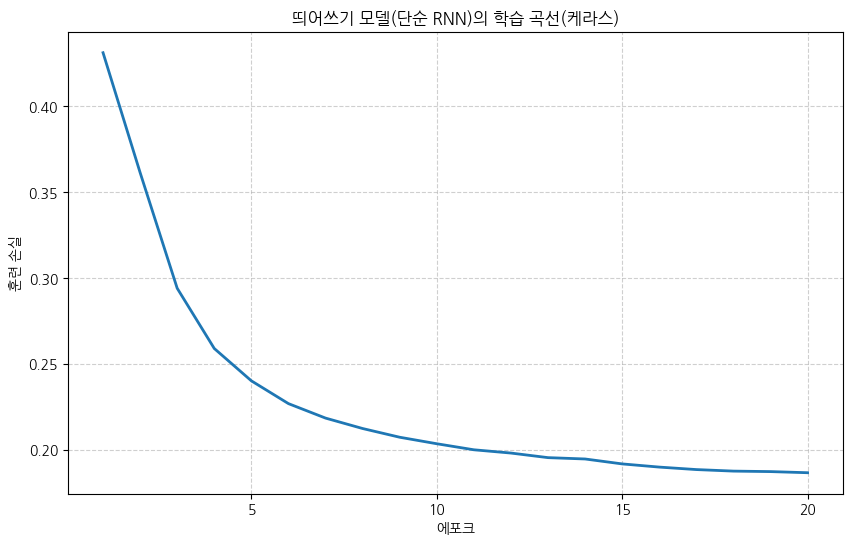

In [12]:
viz.plot_history(
    history_rnn.history['loss'],
    title='띄어쓰기 모델(단순 RNN)의 학습 곡선(케라스)', y_label='훈련 손실',
)

## 5. 예측 — 슬라이딩 윈도우를 한 번에

본문 [코드 6-16]의 `make_spacing()`은 배치 크기가 1인 데이터로더를 만들어
윈도우를 하나씩 모델에 넣고, 결과를 문자열에 이어 붙였다.

```python
for input_sample, _ in dataloader:
    input_sample = input_sample.to(device)
    prediction = model(input_sample)
    is_spacing = torch.argmax(prediction, dim=1).item()
    spacing_sequence += str(is_spacing)
```

케라스의 `predict()`는 데이터로더를 통째로 받아 **모든 윈도우의 예측을 한 번에** 돌려준다.
루프도, `.to(device)`도, `model.eval()`도 `torch.no_grad()`도 없다.

```python
predictions = model.predict(dataloader, verbose=0)   # (윈도우 수, 2)
spacing_sequence = ''.join(str(i) for i in predictions.argmax(axis=1))
```

예측 결과를 문자열로 되돌리는 뒷부분은 본문과 같다. 모델 바깥의 코드이기 때문이다.

In [13]:
# 본문 [코드 6-16] 의 케라스판
def make_spacing(model, input_string, vocab, sequence_length):
    # 예측용 입력 문자열 생성(정답 문자열은 길이만 맞으면 되므로 그대로 사용)
    input_sequence, target_sequence = making_spacing_example(input_string)
    dataset = SpacingDataset(input_sequence, target_sequence, vocab, sequence_length)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    # 모든 윈도우의 예측을 한 번에 얻음
    predictions = model.predict(dataloader, verbose=0)       # (윈도우 수, 2)
    spacing_sequence = ''.join(str(i) for i in predictions.argmax(axis=1))

    # 앞 부분의 글자(윈도우의 크기 - 1개)는 예측 대상에서 제외
    head = input_sequence[:sequence_length - 1]
    tail = ''
    start_idx = sequence_length - 1
    # 0과 1의 예측 결과로부터 입력 문자열에 띄어쓰기 추가
    for i, mark in enumerate(spacing_sequence):
        tail += input_sequence[start_idx + i]
        if mark == '1':
            tail += ' '
    return head, tail


# 어휘 사전에 없는 문자를 미리 제거(예외 처리)
def filter_unknown_chars(text, vocab):
    lowered = text.lower()
    return ''.join(c for c in lowered if c.isspace() or c in vocab)

In [14]:
# 참고 - 예측 결과를 본문 형태로 출력하는 출력 형식 정리 도우미 함수
#   X: 띄어쓰기가 없는 위치에 띄어씀(FP) -> 그 공백 칸 위에 표시
#   V: 띄어써야 하는데 띄어쓰지 않음(FN) -> 빠진 공백 바로 뒤 글자 위에 표시
def result_formatting(head, tail, original_text, width=79):
    _, norm_target = making_spacing_example(original_text)
    skip_size = len(head)               # head 부분은 평가 대상 외

    # tail에서 글자(content)와 글자 뒤 공백 예측(0/1)을 복원
    content, pred_marks = [], []
    i = 0
    while i < len(tail):
        content.append(tail[i])
        if i + 1 < len(tail) and tail[i + 1] == ' ':
            pred_marks.append(1)
            i += 2
        else:
            pred_marks.append(0)
            i += 1
    target_marks = [int(c) for c in norm_target[skip_size:]][:len(pred_marks)]

    n = len(content)
    text_chars, marker_chars = [], []
    tp = tn = fp = fn = 0
    pending_v = False                   # 직전 글자에서 공백이 누락(FN)됐는가
    for j, ch in enumerate(content):
        marker_chars.append('V' if pending_v else ' ')
        text_chars.append(ch)
        pending_v = False
        if j == n - 1:                  # 마지막 글자 뒤의 공백은 평가, 표시 제외
            continue
        p = pred_marks[j]
        t = target_marks[j] if j < len(target_marks) else 0
        if p == 1:                      # 공백을 넣은 경우
            text_chars.append(' ')
            if t == 0:                  # 넣지 말아야 할 공백 -> 위양성(FP)
                fp += 1
                marker_chars.append('X')
            else:                       # 올바르게 넣은 공백 -> 진양성(TP)
                tp += 1
                marker_chars.append(' ')
        else:                           # 공백을 넣지 않은 경우
            if t == 1:                  # 넣어야 할 공백을 빠뜨림 -> 위음성(FN)
                fn += 1
                pending_v = True
            else:                       # 올바르게 붙여 씀 -> 진음성(TN)
                tn += 1

    total = tp + tn + fp + fn
    acc = (tp + tn) / total * 100 if total > 0 else 0

    text = ''.join(text_chars)
    marker = ''.join(marker_chars)
    lines = ['-' * width]
    for start in range(0, len(text), width):
        lines.append(marker[start: start + width])
        lines.append(text[start: start + width])
    lines.append('-' * width)
    lines.append(
        f'* TP={tp}, TN={tn}, FP(X)={fp}, FN(V)={fn} '
        f'(정확도: {tp + tn}/{total} = {acc:.1f}%)'
    )
    return '\n'.join(lines)

In [15]:
# 테스트 입력 - 본문 및 예제 노트북과 동일
test_inputs = [
    # 첫 번째 테스트 입력: 학습 데이터의 부분 문자열
    'The Witch of the South. She is the most powerful of all the Witches, '
    'and rules over the Quadlings. Besides, her castle stands on the edge '
    'of the desert, so she may know a way to cross it.',
    # 두 번째 테스트 입력: 학습 데이터에 포함되지 않은 문자열
    'It was out of sight. The Queen told them to go at once and get all '
    'her people. That would make Dorothy happy. So I will say good-bye, '
    'said the Princess.',
]

for i, test_input in enumerate(test_inputs):
    safe_input = filter_unknown_chars(test_input, vocab)
    print(f'\n-- {i + 1}번째 테스트 입력 --')
    head, tail = make_spacing(model_rnn, safe_input, vocab, SEQUENCE_LENGTH)
    print(result_formatting(head, tail, safe_input))


-- 1번째 테스트 입력 --
-------------------------------------------------------------------------------
              X      V                                            X        X X 
the most power ful ofall the witches, and rules over the quadlings . beside s ,
   X        V    X V        X  V                               V               
 he r castlestand son the ed geof the desert, so she may know away to cross it.
-------------------------------------------------------------------------------
* TP=25, TN=88, FP(X)=7, FN(V)=5 (정확도: 113/125 = 90.4%)

-- 2번째 테스트 입력 --


-------------------------------------------------------------------------------
  X      X                                      X                              
to ld the m to go at once and get all her people . that would make dorothy happ
                     X                        
y. so i will say good -bye, said the princess.
-------------------------------------------------------------------------------
* TP=23, TN=70, FP(X)=4, FN(V)=0 (정확도: 93/97 = 95.9%)


## 6. LSTM으로 교체 — 본문 [코드 6-17]과 대칭

본문은 `nn.RNN`을 `nn.LSTM`으로 바꾸기만 하면 된다고 했다. 생성자 인자와 출력 형태가
같기 때문이다. 케라스도 마찬가지다. `layers.SimpleRNN`을 `layers.LSTM`으로 바꾸면 끝이다.
`build_spacing_model()`이 계층 클래스를 인자로 받도록 만들어 둔 것이 이 때문이다.

파라미터 수의 차이는 여기서 네 배로 벌어진다. LSTM은 입력 게이트, 망각 게이트,
셀 후보, 출력 게이트의 **네 부품**을 갖고 각각에 편향이 붙기 때문이다.
두 프레임워크 모두 네 부품의 가중치를 하나의 큰 행렬에 묶어 두므로
`hidden_size`가 256이면 가중치 행렬의 한 변이 `4 x 256 = 1024`가 된다.

In [16]:
keras.utils.set_random_seed(SEED)
model_lstm = build_spacing_model(layers.LSTM)
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 25, 256)        │       325,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,458 (3.25 MB)

 Trainable params: 851,458 (3.25 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# 파이토치 SpacingLSTM 과 파라미터 수 대조 (본문 [코드 6-17])
class SpacingLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):               # 입력 x: (B, S, input_size)
        outputs, _ = self.lstm(x)       #      -> (B, S, hidden_size)
        last_hidden = outputs[:, -1, :] #      -> (B, hidden_size)
        return self.fc(last_hidden)     #      -> (B, output_size)


torch_lstm = SpacingLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
torch_lstm_total = common.count_params(torch_lstm)
keras_lstm_total = model_lstm.count_params()

print(f'{"":<12}{"파이토치":>12}{"케라스":>12}{"차이":>10}')
print(f'{"단순 RNN":<12}{torch_total:>12,}{keras_total:>12,}'
      f'{torch_total - keras_total:>10,}')
print(f'{"LSTM":<12}{torch_lstm_total:>12,}{keras_lstm_total:>12,}'
      f'{torch_lstm_total - keras_lstm_total:>10,}')
print(f'\nLSTM 의 게이트 수: 4  ->  차이도 4배 '
      f'({(torch_lstm_total - keras_lstm_total) // (torch_total - keras_total)}배)')

                    파이토치         케라스        차이
단순 RNN           213,762     213,250       512
LSTM             853,506     851,458     2,048

LSTM 의 게이트 수: 4  ->  차이도 4배 (4배)


In [18]:
keras.utils.set_random_seed(SEED)
model_lstm = build_spacing_model(layers.LSTM)
history_lstm = compile_and_fit(model_lstm)

Epoch 1/20


/home/crapas/work/doc_checker/.venv/lib/python3.14/site-packages/keras/src/backend/torch/rnn.py:656: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  outputs, h_n, c_n = torch._VF.lstm(


1428/1428 - 34s - 24ms/step - accuracy: 0.8392 - loss: 0.3633


Epoch 2/20


1428/1428 - 34s - 24ms/step - accuracy: 0.8904 - loss: 0.2497


...

1428/1428 - 36s - 25ms/step - accuracy: 0.9904 - loss: 0.0257


Epoch 19/20


1428/1428 - 37s - 26ms/step - accuracy: 0.9913 - loss: 0.0239


Epoch 20/20


1428/1428 - 36s - 25ms/step - accuracy: 0.9921 - loss: 0.0218


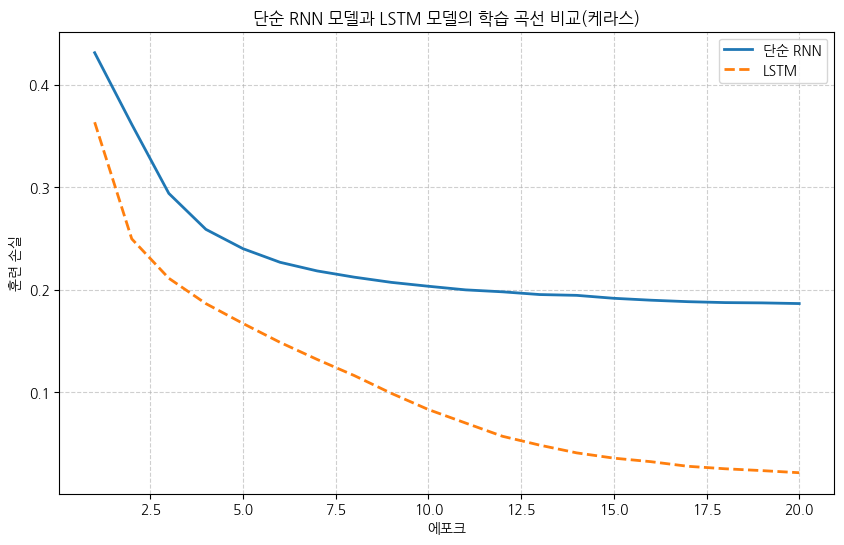

In [19]:
# 두 모델의 학습 곡선 비교(본문 [그림 6-13] 에 해당)
viz.plot_histories(
    {'단순 RNN': history_rnn.history['loss'],
     'LSTM': history_lstm.history['loss']},
    title='단순 RNN 모델과 LSTM 모델의 학습 곡선 비교(케라스)',
    y_label='훈련 손실',
)

In [20]:
# LSTM 모델의 예측 결과
for i, test_input in enumerate(test_inputs):
    safe_input = filter_unknown_chars(test_input, vocab)
    print(f'\n-- {i + 1}번째 테스트 입력 --')
    head, tail = make_spacing(model_lstm, safe_input, vocab, SEQUENCE_LENGTH)
    print(result_formatting(head, tail, safe_input))


-- 1번째 테스트 입력 --
-------------------------------------------------------------------------------
                                                        V                      
the most powerful of all the witches, and rules over thequadlings. besides, her
                                                                            
 castle stands on the edge of the desert, so she may know a way to cross it.
-------------------------------------------------------------------------------
* TP=29, TN=95, FP(X)=0, FN(V)=1 (정확도: 124/125 = 99.2%)

-- 2번째 테스트 입력 --
-------------------------------------------------------------------------------
               V V                                              X              
told them to goatonce and get all her people. that would make do rothy happy. s
   V            X    X          V        
o iwill say good -bye , said theprincess.
-------------------------------------------------------------------------------
* TP=19, TN=71, FP(X)=3, FN(V)

### 두 모델의 예측 결과 읽기

첫 번째 테스트 입력은 학습에 사용한 텍스트의 일부다. 여기에서는 LSTM이 90.4%에서 99.2%로
크게 앞선다. 본문이 설명한 대로 긴 문맥을 더 잘 활용한 결과다.

두 번째 테스트 입력은 학습에 사용하지 않은 문장이다. 여기에서는 두 모델이 비슷하고,
오히려 단순 RNN이 조금 낫다(95.9% 대 92.8%). LSTM의 훈련 정확도가 99%를 넘긴 것을 보면
이미 과적합이 진행된 상태다. 본문 [그림 6-12]가 검증 F1 점수로 보여 준 것과 같은 현상으로,
훈련 손실이 계속 줄어도 처음 보는 데이터에서는 더 나아지지 않는다.

구체적인 숫자는 실행할 때마다 달라지지만, **학습 데이터 안에서 LSTM이 앞서고 그 밖에서는
격차가 줄어드는** 모습은 본문의 설명과 어긋나지 않는다. 6-3절이 조기 종료를 이야기한 이유이기도 하다.

## 7. 속도 — 추상화가 새는 곳

여기서 예상 밖의 일이 벌어진다. 위의 학습 로그에서 에포크당 시간을 비교해 보면
**LSTM이 단순 RNN보다 빠르다.** LSTM은 게이트가 네 개라 계산량이 몇 배 많은데도 그렇다.

이유는 cuDNN에 있다. 3절에서 파이토치가 편향을 두 개 두는 이유로 언급했던 그 라이브러리다.
cuDNN은 순환 신경망의 시점 반복을 GPU 커널 하나로 융합해 처리하는데, 케라스의 파이토치 백엔드는
`LSTM`과 `GRU`에 대해서는 이 경로를 타지만 **`SimpleRNN`에는 그런 경로가 없다.**
`SimpleRNN`은 시점 25개를 파이썬 수준에서 하나씩 돌린다.

파이토치는 `nn.RNN`, `nn.LSTM` 모두 cuDNN 경로를 탄다. 직접 재서 확인해 보자.

In [21]:
# 같은 조건에서 파이토치 구현의 1 에포크 시간 측정
import torch.optim as optim


# model_class: 본문의 SpacingRNN 또는 SpacingLSTM
def measure_torch_epoch(model_class):
    device = common.get_device()
    model = model_class(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    model.train()
    start = time.time()
    for inputs, labels in spacing_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        criterion(model(inputs), labels).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return time.time() - start


torch_rnn_sec = measure_torch_epoch(SpacingRNN)
torch_lstm_sec = measure_torch_epoch(SpacingLSTM)

# 케라스는 앞의 학습에서 기록해 둔 에포크당 평균 시간을 사용
keras_rnn_sec = history_rnn.epoch_seconds
keras_lstm_sec = history_lstm.epoch_seconds

print(f'{"":<12}{"파이토치":>12}{"케라스":>12}{"비율":>10}')
print(f'{"단순 RNN":<12}{torch_rnn_sec:>11.1f}초{keras_rnn_sec:>11.1f}초'
      f'{keras_rnn_sec / torch_rnn_sec:>9.1f}배')
print(f'{"LSTM":<12}{torch_lstm_sec:>11.1f}초{keras_lstm_sec:>11.1f}초'
      f'{keras_lstm_sec / torch_lstm_sec:>9.1f}배')

CUDA를 사용합니다.


CUDA를 사용합니다.


                    파이토치         케라스        비율
단순 RNN              9.9초       87.6초      8.9배
LSTM               13.0초       34.4초      2.6배


케라스 `LSTM`은 파이토치보다 두 배 남짓 느린 데 그치지만, `SimpleRNN`은 훨씬 크게 벌어진다.
**어느 계층이 빠른 경로를 갖고 있느냐**에 따라 결과가 달라지는 것이다.

여기서 얻을 교훈은 케라스가 느리다는 것이 아니다. 고수준 API는 흔히 쓰이는 길을 빠르게 다져 두고,
그 길에서 벗어나면 성능이 급격히 떨어질 수 있다는 것이다. 어느 쪽이 빠른 길인지는
문서에 적혀 있거나, 이렇게 직접 재 봐야 알 수 있다.

파이토치라고 다르지 않다. 본문이 `nn.RNN`에 준 인자가 조금만 달랐어도 cuDNN 경로를 벗어날 수 있다.
다만 파이토치는 순환 계층의 종류와 무관하게 같은 경로를 쓰므로 편차가 적을 뿐이다.

## 정리

- 순차 데이터의 형태 `(B, S, input_size)`는 두 프레임워크가 같다.
  `batch_first=True`는 케라스에 없다. 케라스는 언제나 배치가 먼저이기 때문이다.
- `nn.RNN(num_layers=2)`는 케라스에서 `SimpleRNN` 계층 두 개로 나뉜다.
  마지막을 제외한 계층에는 `return_sequences=True`를 준다.
- 본문의 `outputs[:, -1, :]`는 마지막 계층의 `return_sequences=False`(기본값)에 해당한다.
- `clip_grad_norm_(max_norm=1.0)`은 `Adam(clipnorm=1.0)`으로 옮겨 간다.
- **파라미터 수는 일치하지 않는다.** 파이토치는 순환 계층마다 편향을 둘(`bias_ih`, `bias_hh`),
  케라스는 하나 갖기 때문이다. 두 식은 수학적으로 같고, 파이토치의 편향 하나는 cuDNN의
  구현 관례를 따르기 위한 잉여다. 차이는 `hidden_size x num_layers x 게이트 수`다.
- 5-3절의 합성곱 신경망에서는 파라미터 수가 정확히 일치했다는 점과 견줘 보자.
  **같은 수식이라도 프레임워크마다 파라미터로 노출하는 방식이 다를 수 있다.**
- 케라스 `LSTM`은 cuDNN 융합 커널 경로를 타지만 `SimpleRNN`에는 그런 경로가 없다.
  그래서 계산량이 많은 LSTM이 단순 RNN보다 빠르다. **고수준 API에는 빠른 길과 느린 길이 있다.**

## 연습 문제

**1.** `build_spacing_model()`에서 마지막 순환 계층에도 `return_sequences=True`를 주면
어떤 오류가 나는지 확인해 보자. 오류 메시지에 적힌 텐서의 형태를 본문의 `(B, S, hidden_size)`,
`(B, hidden_size)`와 대응시켜 설명해 보자.

**2.** `NUM_LAYERS`를 3으로 바꿔 두 프레임워크의 파라미터 수를 다시 세어 보자.
차이가 `hidden_size x num_layers` 공식대로 늘어나는지 확인해 보자.

**3.** 본문 6-3절은 `nn.GRU`도 같은 방식으로 교체할 수 있다고 했다.
`layers.GRU`로 세 번째 모델을 만들어 학습시키고, 학습 곡선을 앞의 두 모델과 비교해 보자.
그리고 GRU의 게이트 수(2개)에 맞춰 파라미터 수의 차이가 얼마가 될지 먼저 예측한 다음 확인해 보자.

> 힌트: 케라스의 `GRU`는 기본값이 `reset_after=True`라서 편향을 두 벌 갖는다.
> 예측이 빗나갔다면 이 인자를 `False`로 두고 다시 세어 보자.

**4.** 4절의 `clipnorm=1.0`을 `clipvalue=1.0`으로 바꿔 학습해 보자.
학습 곡선이 어떻게 달라지는지 관찰하고, 6-3절이 설명한 기울기 클리핑이 왜 `clipnorm` 쪽인지
설명해 보자.

**5.** 5절의 `make_spacing()`은 `predict()`에 배치 크기 `BATCH_SIZE`인 데이터로더를 넘긴다.
본문처럼 배치 크기를 1로 바꾸면 예측 시간이 얼마나 달라지는지 재 보자.

**6.** [도전 문제] 본문 예제 노트북은 원본 순차 데이터를 8:2로 먼저 나눈 뒤 데이터셋을 만들어
과적합을 관찰했다. 같은 방식으로 검증 데이터셋을 만들어 `fit(validation_data=...)`에 넘기고,
`EarlyStopping` 콜백으로 조기 종료를 적용해 보자.

> 힌트: 띄어쓰기는 불균형 분류이므로 정확도보다 F1 점수가 낫다.
> `keras.metrics.F1Score`를 `compile(metrics=...)`에 넣을 수 있다.

**7.** [도전 문제] 파이토치 `SpacingRNN`의 학습된 파라미터를 케라스 모델로 **옮겨** 보자.
가중치는 전치하고, 두 편향은 더해서 하나로 만들면 된다.
옮긴 뒤 두 모델이 같은 입력에 같은 출력을 내는지 확인해 보자.

> 힌트: `keras_layer.set_weights([kernel, recurrent_kernel, bias])` 순서다.
> 3절에서 "두 식은 수학적으로 같다"고 한 주장을 직접 검증하는 문제다.